In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [125]:
data = pd.read_csv('Nat_Gas.csv')

In [126]:
data.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [127]:
data.shape

(48, 2)

In [128]:
data['Dates'] = pd.to_datetime(data['Dates'])

/var/folders/qj/jhdzh4bd3wj28qd2dgxdbhmw0000gn/T/ipykernel_13738/1761356499.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Dates'] = pd.to_datetime(data['Dates'])


In [129]:
data = data.sort_values('Dates')

array([[<Axes: title={'center': 'Dates'}>,
        <Axes: title={'center': 'Prices'}>]], dtype=object)

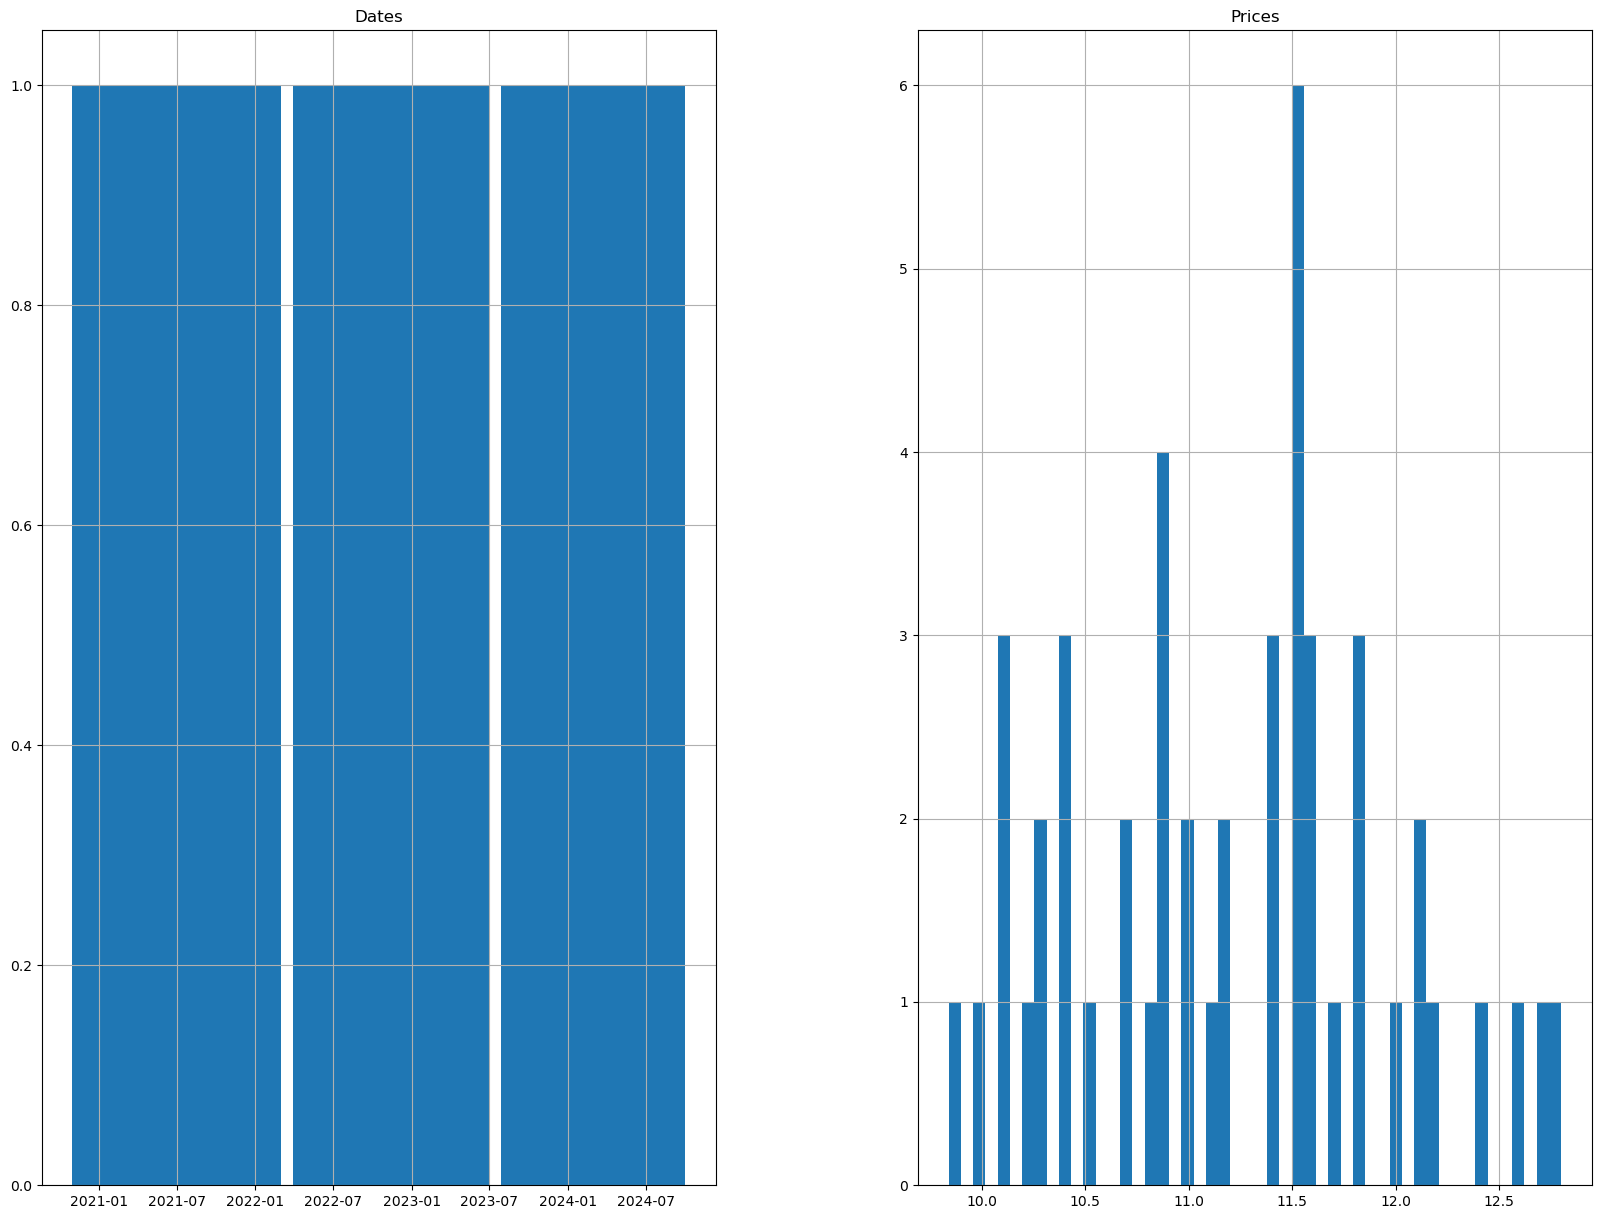

In [130]:
data.hist(bins=50, figsize=(20,15))

In [131]:
data['Days'] = (data['Dates'] - data['Dates'].min()).dt.days

In [132]:
interp_func = interp1d(
    data['Days'],
    data['Prices'],
    kind='linear',
    fill_value='extrapolate'
)

In [133]:
data['Month'] = data['Dates'].dt.month
monthly_avg = data.groupby('Month')['Prices'].mean()

In [134]:
X = data[['Days']]
Y = data['Prices']

model = LinearRegression()
model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [135]:
def estimate_price(input_date):

    input_date = pd.to_datetime(input_date)

    days = (input_date - data['Dates'].min()).days

    last_date = data['Dates'].max()
    future_limit = last_date + pd.DateOffset(years=1)

    if input_date <= last_date:
        return float(interp_func(days))

    elif input_date <= future_limit:

        trend_price = model.predict([[days]])[0]

        month = input_date.month
        seasonal_effect = monthly_avg[month] - monthly_avg.mean()

        return float(trend_price + seasonal_effect)

    else:
        raise ValueError("Date beyond forecast range")

In [136]:
print(estimate_price("2022-06-15"))

10.55


In [137]:
print(estimate_price("2025-05-15"))

11.993850845764632


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
